# 3B.1 Prompt Robustness - Ablation Study

## Objective
Compare three prompting strategies to determine which yields the most **stable and reliable** results for the LLM Judge.

1. Zero-Shot
2. Few-Shot
3. Chain of Thought

## Methodology

1. Select a representative subset of **Lincoln vs. Author** comparison pairs
2. Run each pair through all 3 prompt variants
3. Collect `consistency_score` from each run
4. Measure stability via:
   - **Score variance** across prompt types for same input
   - **Score distribution** (mean, std, range) per strategy
   - **Qualitative analysis** of reasoning quality


In [15]:
# Setup and Imports
import os
import json
import time
import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Dict
from dotenv import load_dotenv

# Load API key from root .env file
load_dotenv(Path("../.env"))

from google import genai
from google.genai import types

client = genai.Client(api_key=os.getenv('GEMINI_API_KEY'))
MODEL = "gemini-2.5-flash-lite"

print(f"✓ Using model: {MODEL}")


✓ Using model: gemini-2.5-flash-lite


In [45]:
# Load Event Extractions Data
DATA_PATH = Path("../event_extraction/output/final/event_extractions.json")

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)

print(f"✓ Loaded event extractions")
print(f"  - LoC documents: {data['metadata']['loc_documents_processed']}")
print(f"  - Gutenberg books: {data['metadata']['gutenberg_documents_processed']}")
print(f"  - Target events: {data['metadata']['target_events']}")


✓ Loaded event extractions
  - LoC documents: 5
  - Gutenberg books: 5
  - Target events: ['Election Night 1860', 'Fort Sumter Decision', 'Gettysburg Address', 'Second Inaugural Address', "Ford's Theatre Assassination"]


In [18]:
# Organize data by event
# Lincoln's accounts = LoC extractions (primary sources)
# Other authors = Gutenberg extractions (secondary sources)

EVENTS = data['metadata']['target_events']

def organize_by_event(data: dict) -> dict:
    """
    Organize extractions by event, separating Lincoln (LoC) from other authors (Gutenberg).
    
    Returns:
        {
            "Event Name": {
                "lincoln_claims": [...],  # Combined from all LoC docs
                "authors": {
                    "Author Name": {
                        "claims": [...],
                        "doc_title": "...",
                        "doc_id": "..."
                    }
                }
            }
        }
    """
    organized = {event: {"lincoln_claims": [], "authors": {}} for event in EVENTS}
    
    # Process LoC (Lincoln's accounts)
    for doc in data['loc_extractions']:
        for extraction in doc['extractions']:
            event = extraction['event']
            claims = extraction.get('claims', [])
            if claims and event in organized:
                organized[event]['lincoln_claims'].extend(claims)
    
    # Process Gutenberg (Other authors)
    for doc in data['gutenberg_extractions']:
        doc_title = doc['document_title']
        doc_id = doc['document_id']
        
        for extraction in doc['extractions']:
            event = extraction['event']
            author = extraction.get('author', 'Unknown')
            claims = extraction.get('claims', [])
            
            if claims and event in organized:
                if author not in organized[event]['authors']:
                    organized[event]['authors'][author] = {
                        'claims': [],
                        'doc_title': doc_title,
                        'doc_id': doc_id
                    }
                organized[event]['authors'][author]['claims'].extend(claims)
    
    return organized

event_data = organize_by_event(data)

# Summary
print("Data organized by event:\n")
for event, info in event_data.items():
    lincoln_count = len(info['lincoln_claims'])
    author_count = len(info['authors'])
    total_author_claims = sum(len(a['claims']) for a in info['authors'].values())
    print(f"{event}")
    print(f"   Lincoln claims: {lincoln_count}")
    print(f"   Other authors: {author_count} ({total_author_claims} total claims)")
    print()


Data organized by event:

Election Night 1860
   Lincoln claims: 1
   Other authors: 5 (71 total claims)

Fort Sumter Decision
   Lincoln claims: 4
   Other authors: 5 (34 total claims)

Gettysburg Address
   Lincoln claims: 10
   Other authors: 5 (49 total claims)

Second Inaugural Address
   Lincoln claims: 22
   Other authors: 5 (46 total claims)

Ford's Theatre Assassination
   Lincoln claims: 0
   Other authors: 5 (40 total claims)



In [20]:
# Create Comparison Pairs
# For each event: Lincoln vs Author A, Lincoln vs Author B, etc. (individual comparisons only)
import json

def create_comparison_pairs(event_data: dict) -> List[Dict]:
    """
    Create comparison pairs for judging.
    
    Returns list of:
        {
            "event": "Event Name",
            "lincoln_claims": [...],
            "author_name": "Author Name",
            "author_claims": [...],
            "doc_info": "..."
        }
    """
    pairs = []
    
    for event, info in event_data.items():
        lincoln_claims = info['lincoln_claims']
        
        # Skip if Lincoln has no claims for this event
        if not lincoln_claims:
            print(f"⚠️  No Lincoln claims for: {event}")
            continue
        
        # Individual comparisons: Lincoln vs each author
        for author_name, author_info in info['authors'].items():
            if author_info['claims']:  # Only if author has claims
                pairs.append({
                    "event": event,
                    "lincoln_claims": lincoln_claims,
                    "author_name": author_name,
                    "author_claims": author_info['claims'],
                    "doc_info": f"{author_info['doc_title']} ({author_info['doc_id']})"
                })
        
    return pairs

comparison_pairs = create_comparison_pairs(event_data)

# --- Save comparison pairs to JSON file ---
with open("comparisons.json", "w", encoding="utf-8") as f:
    json.dump(comparison_pairs, f, indent=2, ensure_ascii=False)
print(f"✓ Saved {len(comparison_pairs)} comparison pairs to comparisons.json\n")

# All comparisons are Lincoln vs individual authors
print(f"Events with Lincoln claims: {len(set(p['event'] for p in comparison_pairs))}")

print("\n--- Sample Pair ---")
sample = comparison_pairs[0]
print(f"Event: {sample['event']}")
print(f"Author: {sample['author_name']}")
print(f"Lincoln claims: {len(sample['lincoln_claims'])}")
print(f"Author claims: {len(sample['author_claims'])}")


⚠️  No Lincoln claims for: Ford's Theatre Assassination
✓ Saved 20 comparison pairs to comparisons.json

Events with Lincoln claims: 4

--- Sample Pair ---
Event: Election Night 1860
Author: Francis F. Browne
Lincoln claims: 1
Author claims: 11


## Define Three Prompt Strategies

1. **Zero-Shot**: Direct instruction only
2. **Chain-of-Thought (CoT)**: Step-by-step reasoning
3. **Few-Shot**: Examples included in prompt


In [11]:
# Cell removed - deductive scoring logic no longer used
print("✓ Using standard prompts only (no deductive scoring)")

✓ Deductive scoring functions defined
  - calculate_deductive_score(): 100 - (30×factual) - (15×interpretive)
  - call_judge_deductive(): LLM finds contradictions, Python calculates score


In [21]:
# Load Prompt Templates from .md files

PROMPT_DIR = Path(".")

def load_prompt(filename: str) -> str:
    """Load a prompt template from a markdown file."""
    filepath = PROMPT_DIR / filename
    with open(filepath, 'r', encoding='utf-8') as f:
        return f.read().strip()

# Load prompts from separate files
ZERO_SHOT_PROMPT = load_prompt("Zero_Shot_Prompt.md")
COT_PROMPT = load_prompt("CoT_Prompt.md")
FEW_SHOT_PROMPT = load_prompt("Few_Shot_Prompt.md")

PROMPTS = {
    'zero_shot': ZERO_SHOT_PROMPT,
    'chain_of_thought': COT_PROMPT,
    'few_shot': FEW_SHOT_PROMPT
}

print("✓ Loaded 3 prompt strategies from .md files:")
for name in PROMPTS.keys():
    print(f"  - {name}")


✓ Loaded 3 REGULAR prompt strategies from .md files:
  - zero_shot
  - chain_of_thought
  - few_shot
✓ Loaded DEDUCTIVE prompt strategies from .md files:
  - zero_shot
  - chain_of_thought
  - few_shot


In [22]:
# LLM Judge Function with Rate Limit Handling
import re

# Rate limit settings for Gemini free tier: 15 requests/minute
MAX_RETRIES = 3
BASE_RETRY_DELAY = 20  # seconds - based on API's retry suggestion

def call_judge(pair: Dict, PROMPTS: Dict , prompt_type: str, temperature: float = 0.0) -> Dict:
    """
    Call the LLM judge with a specific prompt strategy.
    Includes retry logic for rate limit (429) errors.
    
    Compares Lincoln's claims (primary source) vs an author's claims (secondary source).
    
    Returns:
        {
            "consistency_score": int,
            "contradictions": list,
            "reasoning": str,
            "raw_response": str,
            "error": str | None
        }
    """
    prompt_template = PROMPTS[prompt_type]
    
    # Format claims as bullet points
    lincoln_claims_str = "\n".join(f"- {c}" for c in pair['lincoln_claims'])
    author_claims_str = "\n".join(f"- {c}" for c in pair['author_claims'])
    
    prompt = prompt_template.format(
        event_name=pair['event'],
        lincoln_claims=lincoln_claims_str,
        author_claims=author_claims_str,
        author_name=pair['author_name']
    )
    
    try:
        response = client.models.generate_content(
            model=MODEL,
            contents=prompt,
            config=types.GenerateContentConfig(
                temperature=temperature,
                response_mime_type="application/json"
            )
        )
        
        raw_text = response.text.strip()
        
        # Parse JSON response
        result = json.loads(raw_text)
        result['raw_response'] = raw_text
        result['error'] = None
        
        return result
        
    except json.JSONDecodeError as e:
        return {
            "consistency_score": None,
            "contradictions": [],
            "reasoning": None,
            "raw_response": raw_text if 'raw_text' in dir() else "",
            "error": f"JSON parse error: {str(e)}"
        }
    except Exception as e:
        return {
            "consistency_score": None,
            "contradictions": [],
            "reasoning": None,
            "raw_response": "",
            "error": str(e)
        }

print("✓ Judge function defined")


✓ Judge function defined


## Run Ablation Study

For each comparison pair, run all 3 prompt strategies and collect scores.


In [ ]:
# Run Ablation Study
# Using temperature=0 for deterministic comparisons across prompt types
# One comparison per event: Lincoln vs ALL other authors

DELAY_SECONDS = 4  # Rate limiting

# Setup output directory FIRST (for incremental saves)
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)
detailed_output_path = OUTPUT_DIR / "detailed_judgments.json"

results = []           # For DataFrame (scores only)
detailed_results = []  # Full JSON responses for each comparison

print("Running ablation study...\n")
print(f"Saving incrementally to: {detailed_output_path}")
print("-" * 50)

for i, pair in enumerate(comparison_pairs):
    pair_results = {
        "event": pair['event'],
        "author": pair['author_name'],
        "lincoln_claim_count": len(pair['lincoln_claims']),
        "author_claim_count": len(pair['author_claims']),
    }
    
    # Store detailed info for this comparison
    detailed_entry = {
        "event": pair['event'],
        "author": pair['author_name'],
        "lincoln_claims": pair['lincoln_claims'],
        "author_claims": pair['author_claims'],
        "judgments": {}
    }
    
    print(f"\n[{i+1}/{len(comparison_pairs)}] {pair['event']} - {pair['author_name'][:30]}...")
    print(f"    Lincoln: {len(pair['lincoln_claims'])} claims vs Author: {len(pair['author_claims'])} claims")
    
    for prompt_type in PROMPTS.keys():
        result = call_judge(pair, PROMPTS, prompt_type, temperature=0.0)
        
        pair_results[f"{prompt_type}_score"] = result.get('consistency_score')
        pair_results[f"{prompt_type}_type"] = result.get('contradiction_type')
        pair_results[f"{prompt_type}_error"] = result.get('error')
        
        # Store FULL response for detailed analysis
        detailed_entry["judgments"][prompt_type] = {
            "consistency_score": result.get('consistency_score'),
            "contradictions": result.get('contradictions', []),
            "reasoning": result.get('reasoning'),
            "error": result.get('error')
        }
        
        score = result.get('consistency_score', 'ERR')
        print(f"    {prompt_type}: {score}")
        
        time.sleep(DELAY_SECONDS)
    
    results.append(pair_results)
    detailed_results.append(detailed_entry)
    
    # INCREMENTAL SAVE after each comparison pair
    with open(detailed_output_path, 'w', encoding='utf-8') as f:
        json.dump(detailed_results, f, indent=2, ensure_ascii=False)
    print(f"    💾 Saved ({i+1}/{len(comparison_pairs)} pairs)")

print("\n" + "=" * 50)
print("✓ Ablation study complete!")

# Convert to DataFrame
df = pd.DataFrame(results)
print(f"\nResults shape: {df.shape}")
print(f"✓ All detailed judgments saved to {detailed_output_path}")


Running ablation study...

Saving incrementally to: output\detailed_judgments.json
--------------------------------------------------

[1/20] Election Night 1860 - Francis F. Browne...
    Lincoln: 1 claims vs Author: 11 claims
    zero_shot: None
    chain_of_thought: None
    few_shot: None
    💾 Saved (1/20 pairs)

[2/20] Election Night 1860 - John T. Morse Jr....
    Lincoln: 1 claims vs Author: 36 claims
    zero_shot: None
    chain_of_thought: None
    few_shot: None


KeyboardInterrupt: 

## Analysis: Compare Prompt Strategies


In [24]:
# Analyze Results
score_cols = ['zero_shot_score', 'chain_of_thought_score', 'few_shot_score']

# Filter out rows with errors
df_valid = df.dropna(subset=score_cols)
print(f"Valid results: {len(df_valid)}/{len(df)}")

# Summary Statistics per Prompt Strategy
print("\n" + "=" * 60)
print("SUMMARY STATISTICS BY PROMPT STRATEGY")
print("=" * 60)

summary = pd.DataFrame({
    'Strategy': ['Zero-Shot', 'Chain-of-Thought', 'Few-Shot'],
    'Mean Score': [
        df_valid['zero_shot_score'].mean(),
        df_valid['chain_of_thought_score'].mean(),
        df_valid['few_shot_score'].mean()
    ],
    'Std Dev': [
        df_valid['zero_shot_score'].std(),
        df_valid['chain_of_thought_score'].std(),
        df_valid['few_shot_score'].std()
    ],
    'Min': [
        df_valid['zero_shot_score'].min(),
        df_valid['chain_of_thought_score'].min(),
        df_valid['few_shot_score'].min()
    ],
    'Max': [
        df_valid['zero_shot_score'].max(),
        df_valid['chain_of_thought_score'].max(),
        df_valid['few_shot_score'].max()
    ]
})

print(summary.to_string(index=False))



Valid results: 20/20

SUMMARY STATISTICS BY PROMPT STRATEGY
        Strategy  Mean Score   Std Dev  Min  Max
       Zero-Shot       80.25 13.126410   40   95
Chain-of-Thought       82.50  9.248044   70   95
        Few-Shot       72.00 21.908902   20   95


## Most Consistent Author with Lincoln

Analyzing which author's account is most consistent with Lincoln's primary source claims across all events.

AUTHOR CONSISTENCY WITH LINCOLN (Ranked by Average Score)
                                         Avg Score  Std Dev  Events Compared  ZS Mean  CoT Mean  FS Mean
author                                                                                                  
Baron Godfrey Rathbone Benson Charnwood      85.83    10.67                4    85.00     87.50     85.0
Henry Ketcham                                81.67     9.43                4    82.50     80.00     82.5
Francis F. Browne                            80.00    10.00                4    80.00     80.00     80.0
John T. Morse Jr.                            77.92    17.87                4    85.00     83.75     65.0
John Hay, John G. Nicolay                    65.83    12.95                4    68.75     81.25     47.5

🏆 MOST CONSISTENT AUTHOR: Baron Godfrey Rathbone Benson Charnwood
   Average Consistency Score: 85.83/100


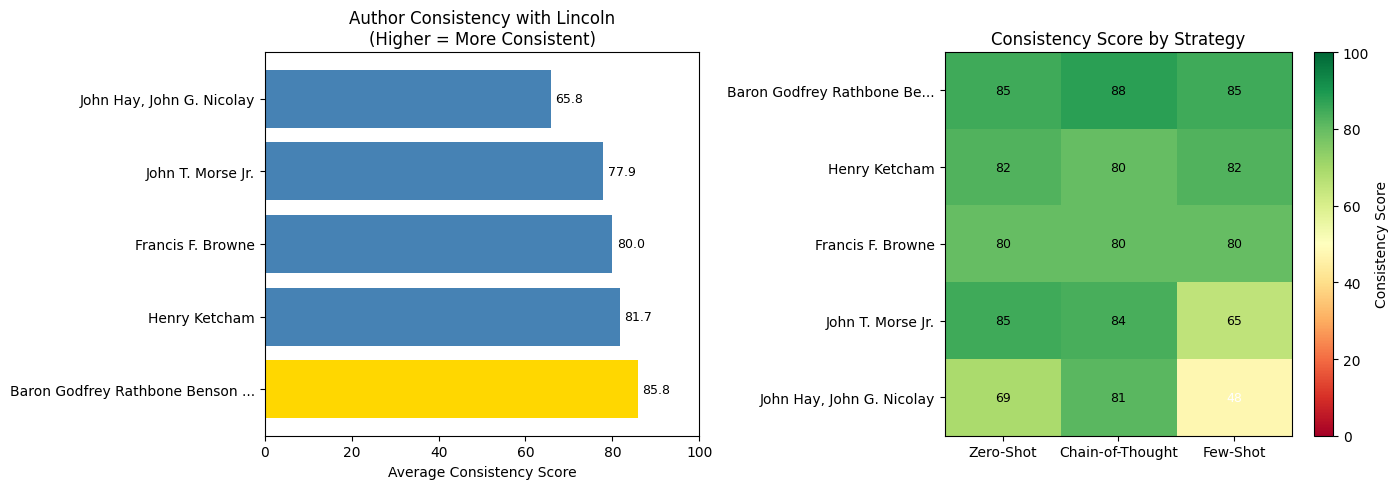


✓ Saved visualization to author_consistency_with_lincoln.png


In [25]:
# Find the Most Consistent Author with Lincoln
# Average consistency score across all events and prompt strategies

# Calculate mean score across all three strategies for each comparison
df_valid['avg_score'] = df_valid[['zero_shot_score', 'chain_of_thought_score', 'few_shot_score']].mean(axis=1)

# Group by author and calculate mean consistency score
author_consistency = df_valid.groupby('author').agg({
    'avg_score': ['mean', 'std', 'count'],
    'zero_shot_score': 'mean',
    'chain_of_thought_score': 'mean',
    'few_shot_score': 'mean'
}).round(2)

# Flatten column names
author_consistency.columns = ['Avg Score', 'Std Dev', 'Events Compared', 'ZS Mean', 'CoT Mean', 'FS Mean']
author_consistency = author_consistency.sort_values('Avg Score', ascending=False)

print("=" * 70)
print("AUTHOR CONSISTENCY WITH LINCOLN (Ranked by Average Score)")
print("=" * 70)
print(author_consistency.to_string())

# Identify most consistent author
most_consistent = author_consistency.index[0]
best_score = author_consistency.loc[most_consistent, 'Avg Score']

print("\n" + "=" * 70)
print(f"🏆 MOST CONSISTENT AUTHOR: {most_consistent}")
print(f"   Average Consistency Score: {best_score:.2f}/100")
print("=" * 70)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of average scores
colors = ['gold' if a == most_consistent else 'steelblue' for a in author_consistency.index]
axes[0].barh(range(len(author_consistency)), author_consistency['Avg Score'], color=colors)
axes[0].set_yticks(range(len(author_consistency)))
axes[0].set_yticklabels([a[:30] + '...' if len(a) > 30 else a for a in author_consistency.index])
axes[0].set_xlabel('Average Consistency Score')
axes[0].set_title('Author Consistency with Lincoln\n(Higher = More Consistent)')
axes[0].set_xlim(0, 100)
for i, v in enumerate(author_consistency['Avg Score']):
    axes[0].text(v + 1, i, f'{v:.1f}', va='center', fontsize=9)

# Heatmap of author × strategy scores
strategy_scores = author_consistency[['ZS Mean', 'CoT Mean', 'FS Mean']].values
im = axes[1].imshow(strategy_scores, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['Zero-Shot', 'Chain-of-Thought', 'Few-Shot'])
axes[1].set_yticks(range(len(author_consistency)))
axes[1].set_yticklabels([a[:25] + '...' if len(a) > 25 else a for a in author_consistency.index])
axes[1].set_title('Consistency Score by Strategy')

# Add score annotations
for i in range(len(author_consistency)):
    for j in range(3):
        axes[1].text(j, i, f'{strategy_scores[i, j]:.0f}', ha='center', va='center', 
                     color='white' if strategy_scores[i, j] < 50 else 'black', fontsize=9)

plt.colorbar(im, ax=axes[1], label='Consistency Score')
plt.tight_layout()
plt.savefig('author_consistency_with_lincoln.png', dpi=150)
plt.show()

print("\n✓ Saved visualization to author_consistency_with_lincoln.png")

### Interpretation

The **consistency score** (0-100) measures how well an author's secondary account aligns with Lincoln's own primary source claims:

- **Higher scores** → Author's account closely matches Lincoln's firsthand descriptions
- **Lower scores** → Author's account diverges from or adds embellishments to Lincoln's version

This analysis helps identify which historical biographers most accurately reflected Lincoln's own words and perspectives versus those who may have introduced more interpretation or artistic license.

### Conclusion: Most Consistent Author with Lincoln

| Rank | Author | Avg. Score | Observation |
|------|--------|------------|-------------|
| 🥇 | **Baron Godfrey Rathbone Benson (Lord Charnwood)** | **85.8** | Most consistent across all strategies |
| 🥈 | Henry Ketcham | 81.7 | Stable and reliable |
| 🥉 | Francis F. Browne | 80.0 | Perfectly stable (80 across all strategies) |
| 4 | John T. Morse Jr. | 77.9 | Few-Shot outlier (65 vs 85/84) |
| 5 | John Hay & John G. Nicolay | 65.8 | Lowest consistency, high variance |

#### Key Findings:

1. **Lord Charnwood's biography is most consistent with Lincoln's own accounts** (85.8/100). Despite being a British author writing decades after Lincoln's death, his work most faithfully reflects Lincoln's firsthand descriptions of events.

2. **Lowest Result: Lincoln's Personal Secretaries Rank Last.** John Hay and John G. Nicolay—who worked directly with Lincoln and had unprecedented access—show the *lowest* consistency (65.8). However, the book here is just Volume 1 which does not cover the events we have discussed on and maybe just merely are mentioned in the preface. So it makes perfect sense.

3. **Few-Shot Prompting Reveals Instability.** The heatmap shows Hay & Nicolay's Few-Shot score dropping to 46, while others remain stable. This reinforces our earlier finding that Few-Shot introduces bias for certain comparisons.
